# Núcleo 1 — Serie histórica de coparticipación (2016-2025)

Este notebook analiza la evolución de la coparticipación federal recibida por las
provincias argentinas, en pesos corrientes y en pesos constantes (deflactados por
IPC), con foco en la provincia de Córdoba.

**Alcance**: 2016-2025. No se incluye 2003-2015 porque no se consiguió una fuente de
inflación confiable para ese tramo (el detalle de por qué está en
`docs/methodology.md`, sección "Supuestos y limitaciones").

**Qué es "coparticipación" acá**: la suma del concepto Ley 23.548 (coparticipación
federal de impuestos, reportado como bruto o neto de Financiamiento Educativo Ley
26.075 según el año) más la compensación del Consenso Fiscal (Ley 27.429, desde 2018).
Ver `docs/methodology.md` para la definición completa y por qué se excluyen otros
regímenes de Recursos de Origen Nacional (IVA, Ganancias, Bienes Personales, etc.).

**Fuente de los datos procesados**: `data/processed/coparticipacion_real.csv`,
generado por `scripts/process_coparticipacion.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Paleta y estilo (validados con el validador de la skill de dataviz del proyecto:
# 4 colores categóricos en orden fijo, pasan los chequeos de daltonismo para líneas).
COLOR_CORDOBA = "#2a78d6"      # slot 1 - azul
COLOR_BUENOS_AIRES = "#eb6834" # slot 2 - naranja
COLOR_SANTA_FE = "#1baf7a"     # slot 3 - aqua
COLOR_MENDOZA = "#eda100"      # slot 4 - amarillo

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

BASE_DIR = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE_DIR / "data" / "processed" / "coparticipacion_real.csv")
df.head()

,provincia,anio,monto_nominal,ipc_promedio_anual,monto_real_base2016
0,Buenos Aires,2016,63573.19190,100.000000,63573.191900
1,Buenos Aires,2017,91194.20990,112.887108,80783.546719
2,Buenos Aires,2018,159762.11140,151.581675,105396.718568
3,Buenos Aires,2019,278598.68840,232.751092,119698.123177
4,Buenos Aires,2020,377235.68866,330.541683,114126.510416


## 1. Verificación rápida de los datos

240 filas esperadas: 24 jurisdicciones (23 provincias + CABA) × 10 años (2016-2025).
`monto_nominal` está en millones de pesos corrientes; `monto_real_base2016` está en
millones de pesos constantes, base promedio 2016 = 100.

In [2]:
print(f"Filas: {len(df)}  |  Provincias: {df['provincia'].nunique()}  |  Años: {df['anio'].min()}-{df['anio'].max()}")
assert len(df) == 240, "Se esperaban 240 filas (24 jurisdicciones x 10 años)"
df.describe()

Filas: 240  |  Provincias: 24  |  Años: 2016-2025


,anio,monto_nominal,ipc_promedio_anual,monto_real_base2016
count,240.000000,2.400000e+02,240.000000,240.000000
mean,2020.500000,4.587959e+05,1952.309866,22921.533288
std,2.878284,1.039713e+06,2960.099498,21782.496197
min,2016.000000,4.853013e+03,100.000000,4853.013200
25%,2018.000000,2.725496e+04,151.581675,11208.539486
50%,2020.500000,8.101522e+04,410.548271,17216.548544
75%,2023.000000,4.450936e+05,1975.006925,24382.146210
max,2025.000000,1.023990e+07,8966.166533,137258.094854


## 2. Evolución real de la coparticipación de Córdoba

En pesos constantes (base 2016), para aislar el efecto de la inflación y ver si la
provincia recibió más o menos poder de compra a lo largo del tiempo.

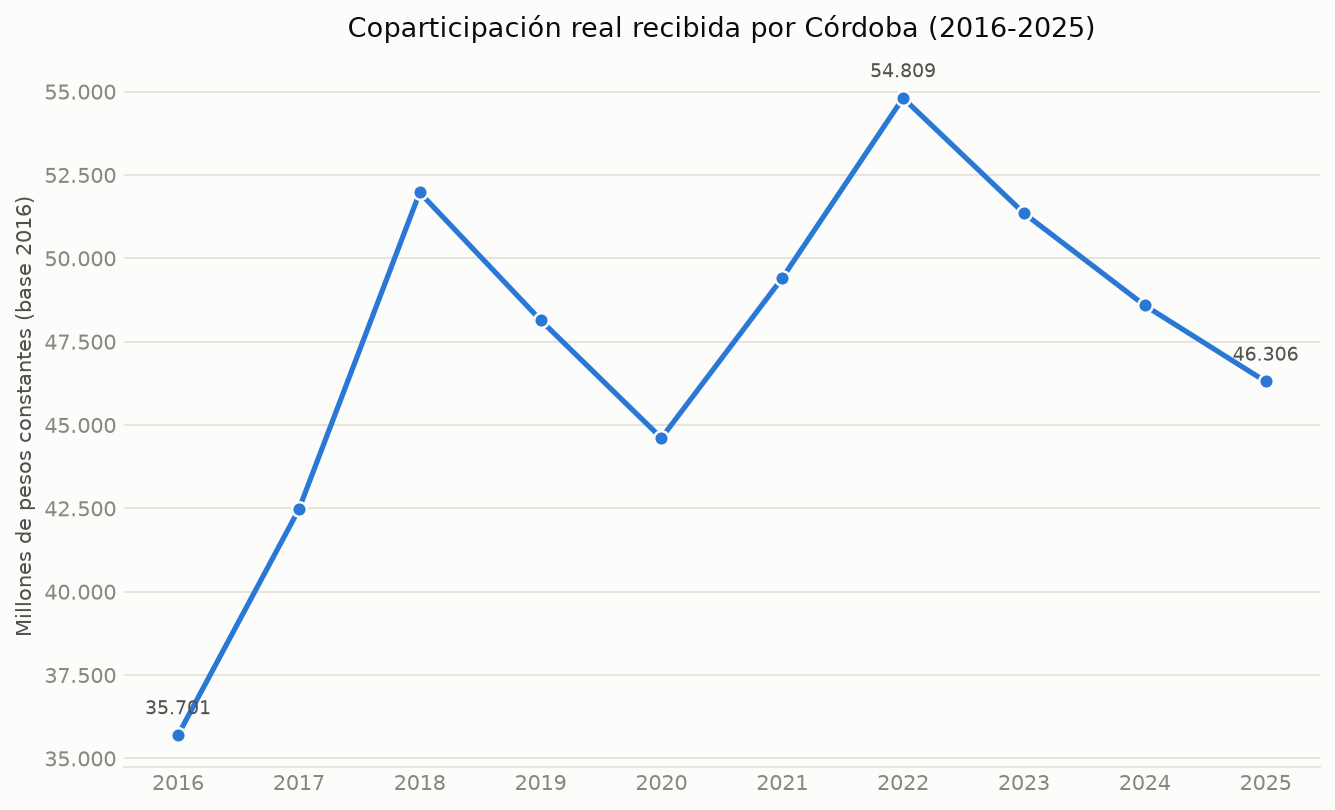

In [3]:
cordoba = df[df["provincia"] == "Córdoba"].sort_values("anio")

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
ax.plot(
    cordoba["anio"], cordoba["monto_real_base2016"],
    color=COLOR_CORDOBA, linewidth=2.5, marker="o", markersize=7,
    markerfacecolor=COLOR_CORDOBA, markeredgecolor=SURFACE, markeredgewidth=1.2,
)

# Etiquetas directas selectivas: primer punto, máximo y último punto (no todos, para no saturar).
idx_max = cordoba["monto_real_base2016"].idxmax()
for idx in [cordoba.index[0], idx_max, cordoba.index[-1]]:
    row = cordoba.loc[idx]
    ax.annotate(
        f"{row['monto_real_base2016']:,.0f}".replace(",", "."),
        (row["anio"], row["monto_real_base2016"]),
        textcoords="offset points", xytext=(0, 10), ha="center",
        fontsize=9, color=INK_SECONDARY,
    )

ax.set_title("Coparticipación real recibida por Córdoba (2016-2025)", fontsize=13, color=INK_PRIMARY, pad=14)
ax.set_ylabel("Millones de pesos constantes (base 2016)", fontsize=10)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cordoba_evolucion_real_2016_2025.png", dpi=300, facecolor=SURFACE)
plt.show()

**Lectura**: la coparticipación real de Córdoba creció entre 2016 y 2018, cayó en
2019-2020 (coincide con la recesión de 2019 y la pandemia), se recuperó hasta alcanzar
su punto más alto en 2022, y volvió a caer en el período 2023-2025 — consistente con el
contexto de ajuste fiscal de esos años a nivel nacional. En pesos constantes, 2025 está
por debajo del pico de 2022 pero por encima del nivel de 2016-2017.

## 3. Comparativo: Córdoba vs. provincias de referencia

Se compara contra Buenos Aires, Santa Fe y Mendoza. **Importante**: esta es una
comparación en niveles absolutos de pesos (no per cápita), así que Buenos Aires —
la provincia más poblada del país — se ve muy por encima solo por su tamaño. Una
comparación per cápita o como porcentaje del gasto provincial queda para los
próximos núcleos de este proyecto.

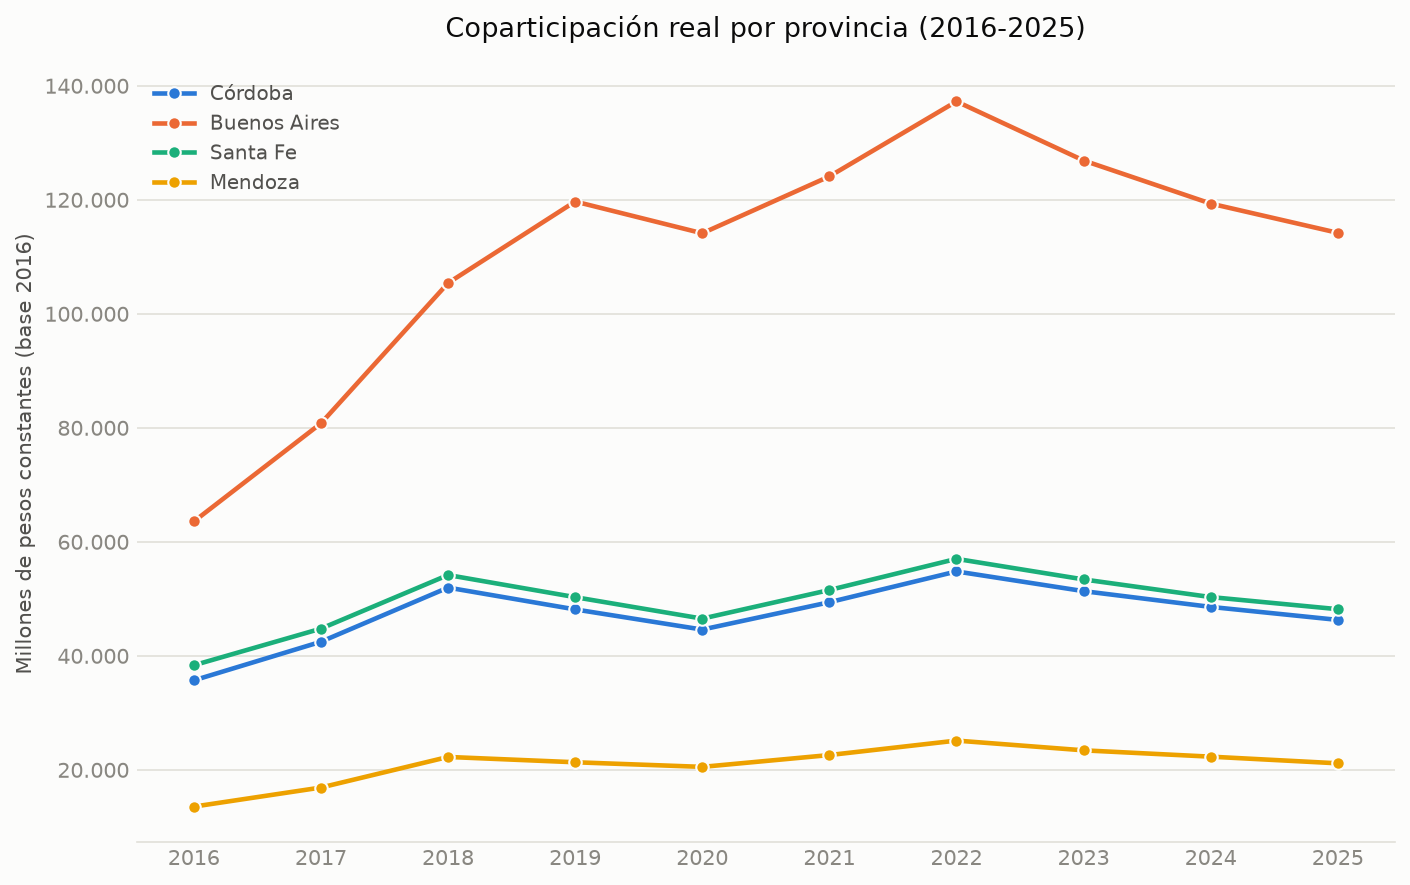

In [4]:
provincias_referencia = ["Córdoba", "Buenos Aires", "Santa Fe", "Mendoza"]
colores = {
    "Córdoba": COLOR_CORDOBA,
    "Buenos Aires": COLOR_BUENOS_AIRES,
    "Santa Fe": COLOR_SANTA_FE,
    "Mendoza": COLOR_MENDOZA,
}

fig, ax = plt.subplots(figsize=(9.5, 6), dpi=150)
for provincia in provincias_referencia:
    serie = df[df["provincia"] == provincia].sort_values("anio")
    ax.plot(
        serie["anio"], serie["monto_real_base2016"],
        color=colores[provincia], linewidth=2.2, marker="o", markersize=6,
        markerfacecolor=colores[provincia], markeredgecolor=SURFACE, markeredgewidth=1,
        label=provincia,
    )

ax.set_title("Coparticipación real por provincia (2016-2025)", fontsize=13, color=INK_PRIMARY, pad=14)
ax.set_ylabel("Millones de pesos constantes (base 2016)", fontsize=10)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
legend = ax.legend(frameon=False, loc="upper left", fontsize=9.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparativo_provincias_real_2016_2025.png", dpi=300, facecolor=SURFACE)
plt.show()

## 4. Conclusiones y próximos pasos

- La coparticipación real de Córdoba siguió una trayectoria muy similar a la de Santa
  Fe y Mendoza (caída en 2019-2020, pico en 2022, caída en 2023-2025), lo que sugiere
  que el patrón responde más a la dinámica agregada del régimen de coparticipación
  (masa total distribuida, no las reglas de reparto entre provincias) que a factores
  específicos de cada provincia.
- Buenos Aires recibe montos absolutos muy superiores al resto por ser la provincia
  más poblada — no es comparable en este formato sin ajustar por población o por otra
  base (eso se aborda en el Núcleo 2, "Aporte vs. recibo por provincia").
- Limitaciones a tener en cuenta (detalladas en `docs/methodology.md`): alcance
  acotado a 2016-2025 por disponibilidad de IPC confiable, y la definición de
  "coparticipación" usada excluye otros regímenes de Recursos de Origen Nacional.